In [3]:
import pandas as pd
import joblib
import shap

model = joblib.load('../models/best_model.pkl')
df = pd.read_csv('../data/processed/featured_car_data.csv')

X = df.drop(columns=['selling_price'])
y = df['selling_price']

explainer = shap.TreeExplainer(model)

In [4]:
X_sample = X.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

In [5]:
print(type(shap_values))
import numpy as np
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(500, 29)


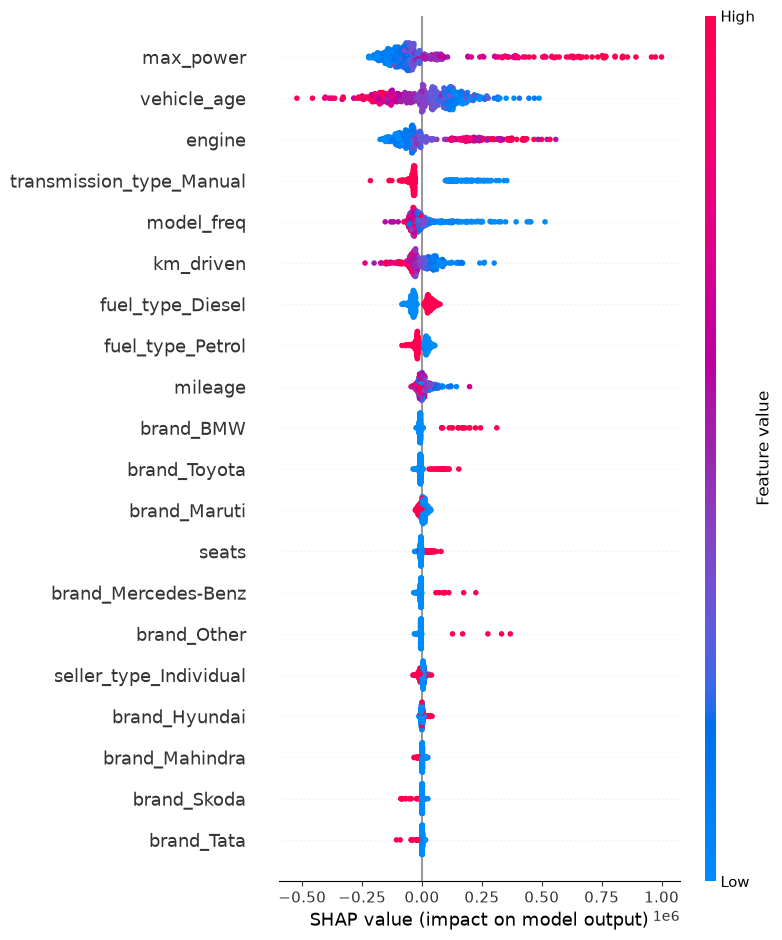

In [6]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig('../models/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
joblib.dump(explainer, '../models/shap_explainer.pkl')
print('Explainer saved.')

Explainer saved.


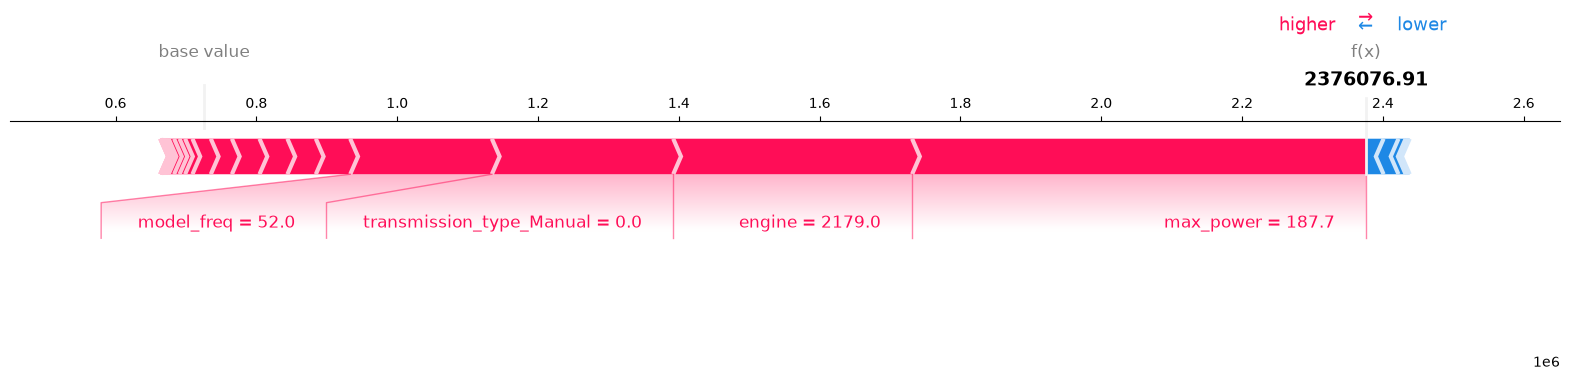

In [8]:
i = 0
shap.force_plot(
    explainer.expected_value, shap_values[i], X_sample.iloc[i],
    matplotlib=True, show=False
)
plt.savefig('../models/shap_force_plot_example.png', dpi=150, bbox_inches='tight')
plt.show()